# 1. Business Understanding

## Business Problem

Training Management Systems (TMS) and Learning Management Systems (LMS)
often struggle to identify students who are likely to withdraw from a course
before it is too late.

Early identification of at-risk students enables instructors and managers to:
- Provide timely interventions
- Improve course completion rates
- Reduce dropout rates
- Improve learning outcomes

---

## Project Goal

Develop a machine learning model that predicts whether a student is likely
to drop out of a course based on learning behavior, assessment performance,
and demographic information.

---

## Objective

Predict:

Dropout = 1
Non-Dropout = 0

where:

Dropout = Student whose final_result = "Withdrawn"

---

## Dataset

Dataset Name:
Open University Learning Analytics Dataset (OULAD)

Source:
Open University, UK

Main Tables Used:
- studentInfo.csv
- studentAssessment.csv
- studentVle.csv
- studentRegistration.csv

Dataset Size:
~32,000 students
~10 million learning activity records

---

## Input Features

Demographic Features:
- Gender
- Age Band
- Highest Education
- Disability Status

Learning Activity Features:
- Total Clicks
- Active Days
- Engagement Score

Assessment Features:
- Average Assessment Score
- Number of Assessments Completed

---

## Target Variable

dropout

0 = Student completed course
1 = Student withdrew from course

---

## Business Value

For Students:
- Early support and intervention

For Instructors:
- Identify at-risk students

For Training Managers:
- Improve retention rate
- Increase course completion rate
- Optimize training effectiveness

---

## Success Metrics

Primary Metrics:
- Recall
- F1 Score
- ROC-AUC

Secondary Metrics:
- Accuracy
- Precision

Reason:

In dropout prediction, missing a student who is actually at risk
(False Negative) is usually more costly than incorrectly flagging
a student as at risk (False Positive).

Therefore Recall and F1 Score are prioritized.

 # 2. Import libraries

In [88]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    f1_score,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


# 3. Load data

In [2]:
# ============================================
# 1. Load Dataset
# ============================================

student_info = pd.read_csv("dataset/studentInfo.csv")
student_assessment = pd.read_csv("dataset/studentAssessment.csv")
student_vle = pd.read_csv("dataset/studentVle.csv")
student_reg = pd.read_csv("dataset/studentRegistration.csv")
# ============================================
# 2. Generic Inspection Function
# ============================================

def inspect_dataset(df, name):
    print("=" * 60)
    print(f"DATASET: {name}")
    print("=" * 60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nInfo:")
    display(df.info())

    print("\nMissing Values:")
    display(df.isnull().sum())

    print("\nHead:")
    display(df.head())

    print("\nDescribe:")
    display(df.describe(include='all'))




In [3]:
# ============================================
# 3. Inspect Student Info
# ============================================

inspect_dataset(student_info, "Student Info")


DATASET: Student Info

Shape:
(32593, 12)

Columns:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result

None


Missing Values:


code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64


Head:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass



Describe:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN


In [4]:
# ============================================
# 4. Inspect Student Assessment
# ============================================

inspect_dataset(student_assessment, "Student Assessment")


DATASET: Student Assessment

Shape:
(173912, 5)

Columns:
['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


None


Missing Values:


id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64


Head:


,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0



Describe:


,id_assessment,id_student,date_submitted,is_banked,score
count,173912.000000,1.739120e+05,173912.000000,173912.000000,173739.000000
mean,26553.803556,7.051507e+05,116.032942,0.010977,75.799573
std,8829.784254,5.523952e+05,71.484148,0.104194,18.798107
min,1752.000000,6.516000e+03,-11.000000,0.000000,0.000000
25%,15022.000000,5.044290e+05,51.000000,0.000000,65.000000
50%,25359.000000,5.852080e+05,116.000000,0.000000,80.000000
75%,34883.000000,6.344980e+05,173.000000,0.000000,90.000000
max,37443.000000,2.698588e+06,608.000000,1.000000,100.000000


In [5]:
# ============================================
# 5. Inspect Student VLE
# ============================================

inspect_dataset(student_vle, "Student VLE")

DATASET: Student VLE

Shape:
(10655280, 6)

Columns:
['code_module', 'code_presentation', 'id_student', 'id_site', 'date', 'sum_click']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 10655280 entries, 0 to 10655279
Data columns (total 6 columns):
 #   Column             Dtype
---  ------             -----
 0   code_module        str  
 1   code_presentation  str  
 2   id_student         int64
 3   id_site            int64
 4   date               int64
 5   sum_click          int64
dtypes: int64(4), str(2)
memory usage: 487.8 MB


None


Missing Values:


code_module          0
code_presentation    0
id_student           0
id_site              0
date                 0
sum_click            0
dtype: int64


Head:


,code_module,code_presentation,id_student,id_site,date,sum_click
0,AAA,2013J,28400,546652,-10,4
1,AAA,2013J,28400,546652,-10,1
2,AAA,2013J,28400,546652,-10,1
3,AAA,2013J,28400,546614,-10,11
4,AAA,2013J,28400,546714,-10,1



Describe:


,code_module,code_presentation,id_student,id_site,date,sum_click
count,10655280,10655280,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
unique,7,4,NaN,NaN,NaN,NaN
top,FFF,2014J,NaN,NaN,NaN,NaN
freq,4014499,3619452,NaN,NaN,NaN,NaN
mean,NaN,NaN,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,NaN,NaN,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,NaN,NaN,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,NaN,NaN,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,NaN,NaN,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,NaN,NaN,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00


In [6]:
inspect_dataset(student_reg, "Student Registation")

DATASET: Student Registation

Shape:
(32593, 5)

Columns:
['code_module', 'code_presentation', 'id_student', 'date_registration', 'date_unregistration']

Info:
<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  str    
 1   code_presentation    32593 non-null  str    
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 1.2 MB


None


Missing Values:


code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64


Head:


,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN



Describe:


,code_module,code_presentation,id_student,date_registration,date_unregistration
count,32593,32593,3.259300e+04,32548.000000,10072.000000
unique,7,4,NaN,NaN,NaN
top,BBB,2014J,NaN,NaN,NaN
freq,7909,11260,NaN,NaN,NaN
mean,NaN,NaN,7.066877e+05,-69.411300,49.757645
std,NaN,NaN,5.491673e+05,49.260522,82.460890
min,NaN,NaN,3.733000e+03,-322.000000,-365.000000
25%,NaN,NaN,5.085730e+05,-100.000000,-2.000000
50%,NaN,NaN,5.903100e+05,-57.000000,27.000000
75%,NaN,NaN,6.444530e+05,-29.000000,109.000000


## basic cleaning and choose features:

In [7]:
## student_info 
student_info.dropna(inplace=True)
student_info.drop_duplicates(inplace=True)
student_features= student_info[['id_student','gender', 'age_band','highest_education','imd_band','disability','final_result' ]].copy()

In [8]:
## student_assessment
student_assessment.dropna(inplace=True)
student_assessment.drop_duplicates(inplace=True)

In [9]:
##student_vle
student_vle.dropna(inplace=True)
student_vle.drop_duplicates(inplace=True)
activity_features = student_vle.drop(
    ['code_module', 'code_presentation'],
    axis=1
)

In [10]:
##student_reg
student_reg.drop_duplicates(inplace=True)
registration_features = student_reg[['date_registration','id_student']].copy()


# 4. Feature Engineering 

## student_info
create target ('dropout' col) as int type( 1 = dropout, 0= other poss) and drop original label column:


In [11]:
student_features["dropout"] = (
    student_features["final_result"] == "Withdrawn"
).astype(int)

##student_features = student_features.drop(columns=["final_result"])

## student_assessment


In [12]:
print(student_assessment.columns.tolist())

['id_assessment', 'id_student', 'date_submitted', 'is_banked', 'score']


In [13]:
assessment_features = (
    student_assessment
    .groupby("id_student")
    .agg(
        avg_score=("score", "mean"),
        max_score=("score", "max"),
        min_score=("score", "min"),
        score_std=("score", "std"),
        assessment_count=("id_assessment", "count"),
        last_submission_day=("date_submitted", "max")
    )
    .reset_index()
)
## fill na std because some student only have 1 score( not enough variation to calculate std)
assessment_features["score_std"]=( 
    assessment_features["score_std"].fillna(0)
)
assessment_features.head()

,id_student,avg_score,max_score,min_score,score_std,assessment_count,last_submission_day
0,6516,61.800000,77.0,48.0,10.329569,5,210
1,8462,87.000000,93.0,83.0,4.472136,7,85
2,11391,82.000000,85.0,78.0,3.082207,5,212
3,23629,82.500000,100.0,63.0,20.273135,4,95
4,23698,74.444444,94.0,56.0,13.258121,9,243


## student_vle

In [14]:
print(activity_features.columns.tolist())

['id_student', 'id_site', 'date', 'sum_click']


In [15]:
activity_features = (
    student_vle
    .groupby("id_student")
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        first_activity_day=("date", "min"),
        last_activity_day=("date", "max")
    )
    .reset_index()
)
## add activity span feat
activity_features["activity_span"] = (
    activity_features["last_activity_day"]
    - activity_features["first_activity_day"]
)
## add avr click per day
activity_features["avg_clicks_per_day"] = (
    activity_features["total_clicks"]
    /
    activity_features["active_days"]
)
## remove inf
activity_features["avg_clicks_per_day"] = (
    activity_features["avg_clicks_per_day"]
    .replace([float("inf"), -float("inf")], 0)
)
activity_features.head()

,id_student,total_clicks,active_days,first_activity_day,last_activity_day,activity_span,avg_clicks_per_day
0,6516,2715,159,-23,269,292,17.075472
1,8462,643,56,-6,118,124,11.482143
2,11391,922,40,-5,253,258,23.050000
3,23629,153,16,-6,87,93,9.562500
4,23698,886,70,-18,231,249,12.657143


## student_reg

In [16]:
registration_features["registered_late"] = (
    registration_features["date_registration"] > 0
).astype(int)
registration_features.head()

,date_registration,id_student,registered_late
0,-159.0,11391,0
1,-53.0,28400,0
2,-92.0,30268,0
3,-52.0,31604,0
4,-176.0,32885,0


## Merge everything

In [17]:
df = (
    student_features
    .merge(
        assessment_features,
        on="id_student",
        how="left"
    )
    .merge(
        activity_features,
        on="id_student",
        how="left"
    )
    .merge(
        registration_features,
        on="id_student",
        how="left"
    )
)
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 39400 entries, 0 to 39399
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_student           39400 non-null  int64  
 1   gender               39400 non-null  str    
 2   age_band             39400 non-null  str    
 3   highest_education    39400 non-null  str    
 4   imd_band             39400 non-null  str    
 5   disability           39400 non-null  str    
 6   final_result         39400 non-null  str    
 7   dropout              39400 non-null  int64  
 8   avg_score            32720 non-null  float64
 9   max_score            32720 non-null  float64
 10  min_score            32720 non-null  float64
 11  score_std            32720 non-null  float64
 12  assessment_count     32720 non-null  float64
 13  last_submission_day  32720 non-null  float64
 14  total_clicks         36297 non-null  float64
 15  active_days          36297 non-null  float64
 1

id_student                0
gender                    0
age_band                  0
highest_education         0
imd_band                  0
disability                0
final_result              0
dropout                   0
avg_score              6680
max_score              6680
min_score              6680
score_std              6680
assessment_count       6680
last_submission_day    6680
total_clicks           3103
active_days            3103
first_activity_day     3103
last_activity_day      3103
activity_span          3103
avg_clicks_per_day     3103
date_registration        64
registered_late           0
dtype: int64

## Handle missing value

In [18]:
numeric_cols=[
"avg_score",             
"max_score",            
"min_score",             
"score_std",              
"assessment_count",       
"last_submission_day",    
"total_clicks",           
"active_days",            
"first_activity_day",     
"last_activity_day",      
"date_registration",
"avg_clicks_per_day"]   
df[numeric_cols]= df[numeric_cols].fillna(0)
df.head()

,id_student,gender,age_band,highest_education,imd_band,disability,final_result,dropout,avg_score,max_score,...,assessment_count,last_submission_day,total_clicks,active_days,first_activity_day,last_activity_day,activity_span,avg_clicks_per_day,date_registration,registered_late
0,11391,M,55<=,HE Qualification,90-100%,N,Pass,0,82.0,85.0,...,5.0,212.0,922.0,40.0,-5.0,253.0,258.0,23.050000,-159.0,0
1,28400,F,35-55,HE Qualification,20-30%,N,Pass,0,66.4,70.0,...,5.0,212.0,1409.0,80.0,-10.0,239.0,249.0,17.612500,-53.0,0
2,30268,F,35-55,A Level or Equivalent,30-40%,Y,Withdrawn,1,0.0,0.0,...,0.0,0.0,260.0,12.0,-10.0,12.0,22.0,21.666667,-92.0,0
3,31604,F,35-55,A Level or Equivalent,50-60%,N,Pass,0,76.0,88.0,...,5.0,213.0,2007.0,123.0,-10.0,264.0,274.0,16.317073,-52.0,0
4,32885,F,0-35,Lower Than A Level,50-60%,N,Pass,0,54.4,75.0,...,5.0,222.0,1012.0,70.0,-10.0,247.0,257.0,14.457143,-176.0,0


## Remove leakage columns

In [19]:
X=df.drop(columns = ["id_student","final_result","dropout"])
y=df["dropout"]
X.head()

,gender,age_band,highest_education,imd_band,disability,avg_score,max_score,min_score,score_std,assessment_count,last_submission_day,total_clicks,active_days,first_activity_day,last_activity_day,activity_span,avg_clicks_per_day,date_registration,registered_late
0,M,55<=,HE Qualification,90-100%,N,82.0,85.0,78.0,3.082207,5.0,212.0,922.0,40.0,-5.0,253.0,258.0,23.050000,-159.0,0
1,F,35-55,HE Qualification,20-30%,N,66.4,70.0,60.0,4.335897,5.0,212.0,1409.0,80.0,-10.0,239.0,249.0,17.612500,-53.0,0
2,F,35-55,A Level or Equivalent,30-40%,Y,0.0,0.0,0.0,0.000000,0.0,0.0,260.0,12.0,-10.0,12.0,22.0,21.666667,-92.0,0
3,F,35-55,A Level or Equivalent,50-60%,N,76.0,88.0,71.0,6.892024,5.0,213.0,2007.0,123.0,-10.0,264.0,274.0,16.317073,-52.0,0
4,F,0-35,Lower Than A Level,50-60%,N,54.4,75.0,30.0,20.513410,5.0,222.0,1012.0,70.0,-10.0,247.0,257.0,14.457143,-176.0,0


## Encode catergorical variables

In [20]:
from sklearn.preprocessing import OneHotEncoder
cat_cols= ["gender",                   
"age_band",                  
"highest_education",         
"imd_band",                  
"disability"]
X = pd.get_dummies(X,columns= cat_cols, drop_first=True)
X.head()

,avg_score,max_score,min_score,score_std,assessment_count,last_submission_day,total_clicks,active_days,first_activity_day,last_activity_day,...,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,disability_Y
0,82.0,85.0,78.0,3.082207,5.0,212.0,922.0,40.0,-5.0,253.0,...,False,False,False,False,False,False,False,False,True,False
1,66.4,70.0,60.0,4.335897,5.0,212.0,1409.0,80.0,-10.0,239.0,...,False,True,False,False,False,False,False,False,False,False
2,0.0,0.0,0.0,0.000000,0.0,0.0,260.0,12.0,-10.0,12.0,...,False,False,True,False,False,False,False,False,False,True
3,76.0,88.0,71.0,6.892024,5.0,213.0,2007.0,123.0,-10.0,264.0,...,False,False,False,False,True,False,False,False,False,False
4,54.4,75.0,30.0,20.513410,5.0,222.0,1012.0,70.0,-10.0,247.0,...,False,False,False,False,True,False,False,False,False,False


## Data Quality Check

In [51]:
X.info()
X.isnull().sum()
X.describe()
X.duplicated().sum()
df["dropout"].value_counts()
import re

X.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X.columns
]

<class 'pandas.DataFrame'>
RangeIndex: 39400 entries, 0 to 39399
Data columns (total 26 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   avg_score                                      39400 non-null  float64
 1   score_std                                      39400 non-null  float64
 2   assessment_count                               39400 non-null  float64
 3   last_submission_day                            39400 non-null  float64
 4   total_clicks                                   39400 non-null  float64
 5   first_activity_day                             39400 non-null  float64
 6   last_activity_day                              39400 non-null  float64
 7   date_registration                              39400 non-null  float64
 8   registered_late                                39400 non-null  int64  
 9   gender_M                                       39400 non-null

# 5. Exploratory Data Analysis (EDA)
## Target Distribution:

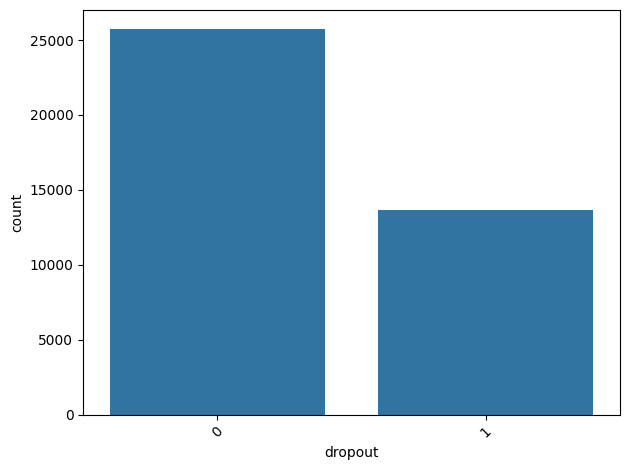

In [52]:
sns.countplot(x='dropout',data=df)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Looking for balance between each variables, if it is imbalanced may need to:
class weights: add weight for minority class
SMOTE: generates sythentic samples for the minority to balance the data set and improve the model's ability to learn
Precision/ Recall instead of Accuracy:...

## Numerical Distribution:

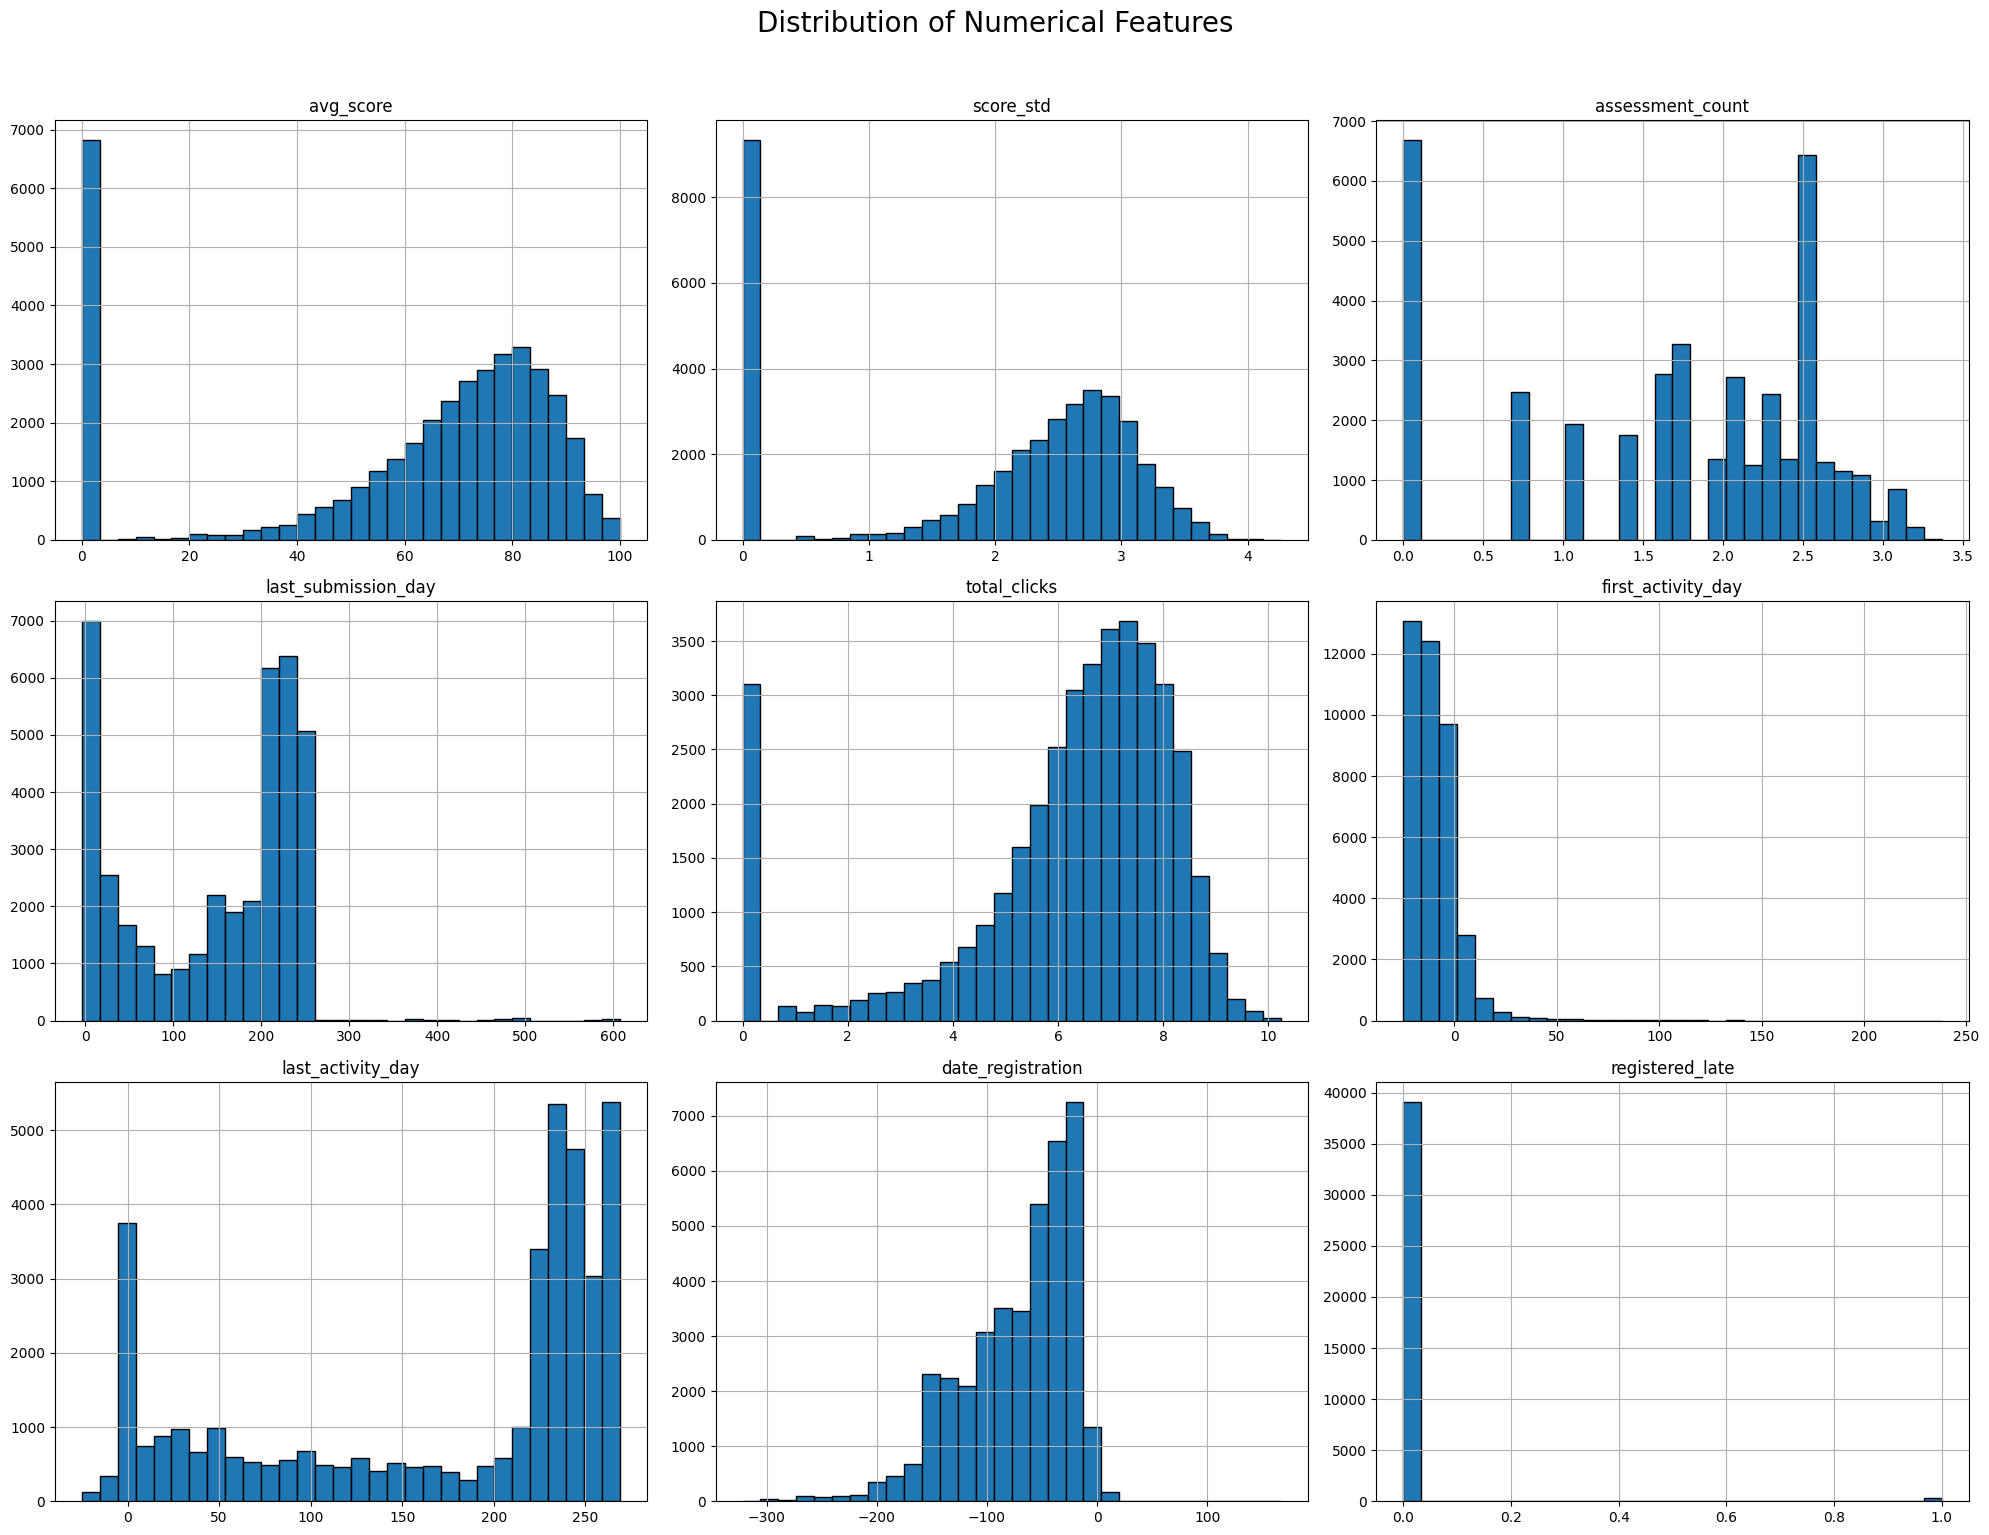

In [53]:
X.hist(
    figsize=(20, 15),   # larger figure
    bins=30,            # smoother distributions
    edgecolor='black'
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=20,
    y=1.02
)

plt.tight_layout()
plt.show()

### Insight:
There are some right skewed variables that we need to scale to improved the performance of the model: total_clicks, avg_clicks_per_day, assessment_count, active_days ,score_std

In [54]:

skewed_cols = [
    "total_clicks",
    "avg_clicks_per_day",
    "assessment_count",
    "active_days",
    "score_std"
]

for col in skewed_cols:
    X[col] = np.log1p(X[col])

KeyError: 'avg_clicks_per_day'

## Box plot:

In [ ]:

plt.figure(figsize=(20, 15))
sns.boxplot(data=X.select_dtypes(include=['int64', 'float64']))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Insight:
There are extremely outliers on last_submission_day which will corrupt our model.

In [ ]:
from scipy.stats.mstats import winsorize
## Winsorize
df["last_submission_day"] = winsorize(
    df["last_submission_day"],
    limits=[0, 0.01]
)

Also have different scale on each features, so standardization is necessary

## Correlation Heatmap:

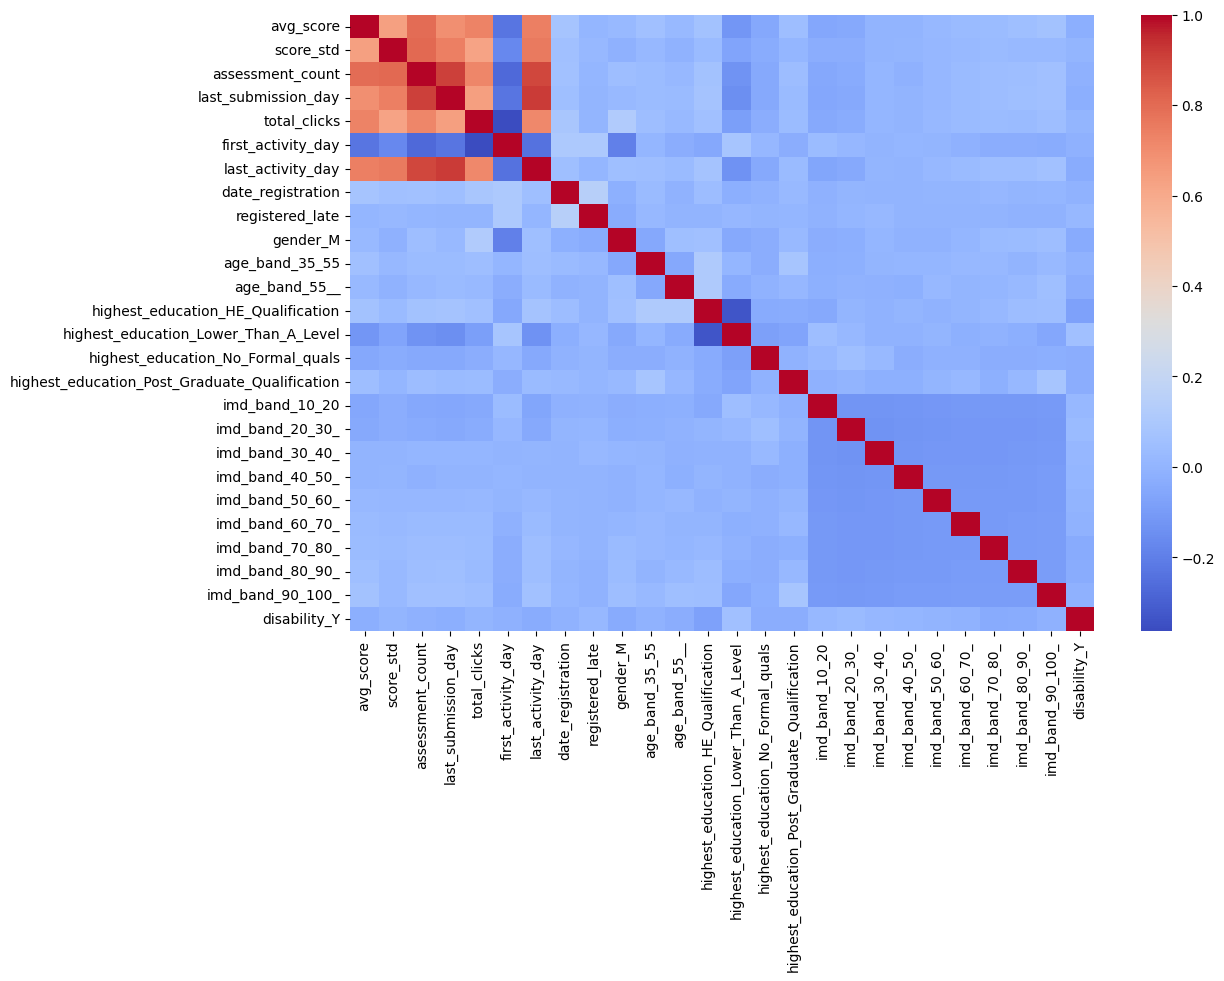

In [55]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [56]:

corr_matrix = corr.abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, col]) and upper.loc[row, col] > 0.8
]

print(high_corr)

[('assessment_count', 'score_std', np.float64(0.8039431584282045)), ('last_submission_day', 'assessment_count', np.float64(0.9065156803753627)), ('last_activity_day', 'assessment_count', np.float64(0.8895950839978521)), ('last_activity_day', 'last_submission_day', np.float64(0.9186382024778998))]


In [57]:
# correlated with target
corr_target = (
    df.corr(numeric_only=True)["dropout"]
    .sort_values(key=abs, ascending=False)
)

print(corr_target)

dropout                1.000000
last_submission_day   -0.577721
last_activity_day     -0.577441
activity_span         -0.492276
max_score             -0.487905
avg_score             -0.458544
assessment_count      -0.449647
active_days           -0.362421
min_score             -0.324248
score_std             -0.274636
total_clicks          -0.259279
avg_clicks_per_day    -0.189130
date_registration     -0.105769
first_activity_day     0.032212
id_student             0.007732
registered_late       -0.005226
Name: dropout, dtype: float64


### Insight: 
highly correlated data: 
    max_score, min_score, avg_score => keep avg_score because it represents the overall performance.    
    active_days, total_clicks => keep total_clicks contains richer info.  
    activity_span, last_activity_day => keep last_activity_day is easier to interpret.
    avg_clicks_per_day,total_clicks => keep total_clicks is easier to explain and more stable.  
    last_submission_day, assessment_count => keep both because they represent different concepts.
                                  
          

In [58]:
drop_cols = [
    "max_score",
    "min_score",
    "active_days",
    "activity_span",
    "avg_clicks_per_day"
]

X = X.drop(columns=drop_cols)

KeyError: "['max_score', 'min_score', 'active_days', 'activity_span', 'avg_clicks_per_day'] not found in axis"

# 6. Train And Test Model
## Split train and test

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(type(X_test))
print(X_test.shape)

<class 'pandas.DataFrame'>
(7880, 26)


## Standard Scaler

In [60]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)


## Train with Logistic Regression (baseline model)

In [61]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Evaluating baseline model

In [62]:
from sklearn.metrics import classification_report
y_pred= model.predict(X_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.87      0.85      5144
           1       0.73      0.64      0.68      2736

    accuracy                           0.79      7880
   macro avg       0.77      0.76      0.76      7880
weighted avg       0.79      0.79      0.79      7880



Based on the bussiness goal, I would want to increase the the recall score. Missing a dropout student is usually more expensive than sending an unnecessary warning.

### Class weight tuning
This helps the model prioritize the lower support class, which is the dropout student in this case.

In [63]:
modeltune = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)
modeltune.fit(X_train_scaled,y_train)
y_predtune= modeltune.predict(X_test_scaled)
y_prob = modeltune.predict_proba(X_test_scaled)[:,1]
print(classification_report(y_test,y_predtune))

              precision    recall  f1-score   support

           0       0.85      0.83      0.84      5144
           1       0.69      0.73      0.71      2736

    accuracy                           0.79      7880
   macro avg       0.77      0.78      0.77      7880
weighted avg       0.80      0.79      0.79      7880



Recall score slightly increased, trade off the precision score as expected.    
Accuracy increased => the model predicts better.

### Recall-Precision table

In [64]:
from sklearn.metrics import precision_score, recall_score

for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (y_prob >= t).astype(int)

    print(
        f"Threshold={t:.1f}",
        f"Precision={precision_score(y_test, pred):.3f}",
        f"Recall={recall_score(y_test, pred):.3f}"
    )


Threshold=0.2 Precision=0.453 Recall=0.946
Threshold=0.3 Precision=0.604 Recall=0.859
Threshold=0.4 Precision=0.665 Recall=0.788
Threshold=0.5 Precision=0.690 Recall=0.730
Threshold=0.6 Precision=0.715 Recall=0.679


At the default threshold of 0.5, the Logistic Regression model achieved 73% precision and 65% recall for dropout prediction. Lowering the threshold to 0.3 increased recall to 86%, allowing the model to identify a substantially larger proportion of at-risk students, at the expense of reduced precision (61%). Since the goal is early intervention, the lower threshold may be preferable.

In [65]:
y_pred_03 = (y_prob >= 0.3).astype(int)
print(classification_report(
    y_test,
    y_pred_03))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      5144
           1       0.60      0.86      0.71      2736

    accuracy                           0.76      7880
   macro avg       0.75      0.78      0.75      7880
weighted avg       0.80      0.76      0.76      7880



### ROC-AUC

In [66]:
from sklearn.metrics import roc_auc_score


auclg = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auclg)

ROC AUC: 0.8505333670977598


This tell me the probability the model rank high risk dropout student higher than low risk dropout student

## Plot ROC curve

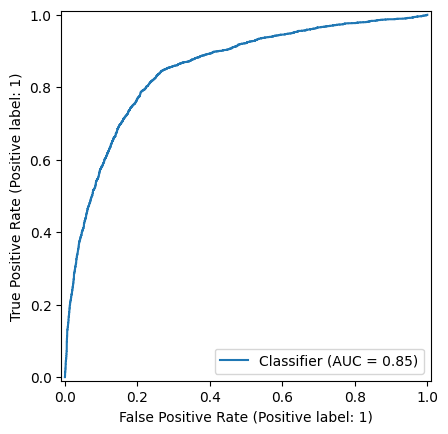

In [67]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

## Compare again Random Forest

In [68]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
print(classification_report(
    y_test,
    rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.78      0.82      5144
           1       0.64      0.76      0.70      2736

    accuracy                           0.77      7880
   macro avg       0.75      0.77      0.76      7880
weighted avg       0.78      0.77      0.77      7880



### Recall-Precision table

In [79]:

for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (rf_prob >= t).astype(int)

    print(
        f"Threshold={t:.1f}",
        f"Precision={precision_score(y_test, pred):.3f}",
        f"Recall={recall_score(y_test, pred):.3f}"
    )


Threshold=0.2 Precision=0.603 Recall=0.926
Threshold=0.3 Precision=0.617 Recall=0.851
Threshold=0.4 Precision=0.627 Recall=0.809
Threshold=0.5 Precision=0.644 Recall=0.760
Threshold=0.6 Precision=0.671 Recall=0.695


Choosing the 0.3 threshold is the most optimal.

In [86]:
y_predrf_03 = (rf_prob >= 0.3).astype(int)
print(classification_report(
    y_test,
    y_predrf_03))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      5144
           1       0.62      0.85      0.72      2736

    accuracy                           0.76      7880
   macro avg       0.76      0.78      0.76      7880
weighted avg       0.80      0.76      0.77      7880



### ROC-AUC

In [71]:

aucrf = roc_auc_score(y_test, rf_prob)
print("ROC AUC:", aucrf)

ROC AUC: 0.8641977992869679


### Plot ROC curve

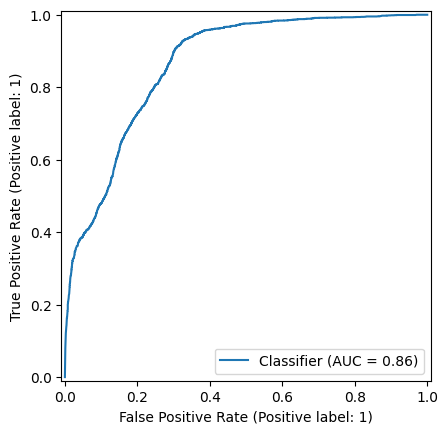

In [72]:


RocCurveDisplay.from_predictions(
    y_test,
    rf_prob
)

## Compare with XGBoost

In [78]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]


### classification rep, ROC_AUC

In [76]:
print(classification_report(y_test, xgb_pred))

print("ROC-AUC:",
      roc_auc_score(y_test, xgb_prob))


              precision    recall  f1-score   support

           0       0.85      0.86      0.85      5144
           1       0.73      0.71      0.72      2736

    accuracy                           0.81      7880
   macro avg       0.79      0.79      0.79      7880
weighted avg       0.81      0.81      0.81      7880

ROC-AUC: 0.8870214716742609


### Recall-Precision table

In [77]:
from sklearn.metrics import precision_score, recall_score

for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred = (xgb_prob >= t).astype(int)

    print(
        f"Threshold={t:.1f}",
        f"Precision={precision_score(y_test, pred):.3f}",
        f"Recall={recall_score(y_test, pred):.3f}"
    )

Threshold=0.2 Precision=0.609 Recall=0.908
Threshold=0.3 Precision=0.649 Recall=0.858
Threshold=0.4 Precision=0.683 Recall=0.792
Threshold=0.5 Precision=0.729 Recall=0.713
Threshold=0.6 Precision=0.787 Recall=0.605


In [83]:
y_predxgb_03 = (xgb_prob >= 0.3).astype(int)
print(classification_report(
    y_test,
    y_predxgb_03))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82      5144
           1       0.65      0.86      0.74      2736

    accuracy                           0.79      7880
   macro avg       0.78      0.81      0.78      7880
weighted avg       0.82      0.79      0.79      7880



### Importance features that affect the model

In [84]:


importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance.head(15))

                                          Feature  Importance
3                             last_submission_day    0.269901
6                               last_activity_day    0.190941
5                              first_activity_day    0.042034
2                                assessment_count    0.041559
0                                       avg_score    0.034237
9                                        gender_M    0.034026
25                                   disability_Y    0.032465
4                                    total_clicks    0.026876
1                                       score_std    0.025484
7                               date_registration    0.024398
15  highest_education_Post_Graduate_Qualification    0.023244
14              highest_education_No_Formal_quals    0.020234
23                                imd_band_80_90_    0.020022
21                                imd_band_60_70_    0.019893
22                                imd_band_70_80_    0.018969


In [89]:
comparison = []

models = {
    "Logistic Regression": (y_pred_03, y_prob),
    "Random Forest": (y_predrf_03 , rf_prob),
    "XGBoost": (y_predxgb_03, xgb_prob)
}

for name, (pred, prob) in models.items():
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.789340,0.648619,0.858187,0.738829,0.887021
1,Random Forest,0.764848,0.617078,0.850512,0.715230,0.864198
0,Logistic Regression,0.755584,0.604167,0.858553,0.709239,0.850533


# 7. Bussiness Report

In [99]:
## False negative and False positive inspection

false_negatives = X_test[
    (y_test == 1) &
    (y_predxgb_03 == 0)
]

print("Number of false negatives:",
      len(false_negatives))

true_positives = X_test[
    (y_test == 1) &
    (y_predxgb_03 == 1)
]

print("Number of true positives:",
      len(true_positives))


Number of false negatives: 388
Number of true positives: 2348


In [100]:
comparison = pd.DataFrame({
    "False_Negative_Mean": false_negatives.mean(numeric_only=True),
    "True_Positive_Mean": true_positives.mean(numeric_only=True)
})

comparison["Difference"] = (
    comparison["False_Negative_Mean"]
    - comparison["True_Positive_Mean"]
)

comparison.sort_values(
    "Difference",
    ascending=False
)

,False_Negative_Mean,True_Positive_Mean,Difference
last_activity_day,236.469072,73.639267,162.829805
last_submission_day,202.832474,51.230835,151.601639
avg_score,71.059386,35.791593,35.267793
date_registration,-70.719072,-78.434838,7.715766
score_std,2.528239,1.101600,1.426639
assessment_count,2.203818,0.828368,1.375450
total_clicks,2.090039,1.446328,0.643712
imd_band_90_100_,0.097938,0.060477,0.037461
gender_M,0.613402,0.597530,0.015872
imd_band_50_60_,0.097938,0.082624,0.015315


Error analysis revealed that most false negative cases differed substantially from the typical dropout profile. Compared with correctly identified dropout students, false negatives exhibited higher average assessment scores, remained active in the learning environment until much later in the course, and submitted assessments more consistently. This suggests that the model successfully captures academically disengaged students but struggles to identify withdrawals driven by factors not represented in the dataset. Future work should incorporate additional behavioral and non-academic features to improve detection of these cases.


## Insight 1: Student Engagement is the Strongest Predictor  

Students who continue accessing the learning platform and submitting assessments later in the course are substantially less likely to withdraw.

Recommendation:

Implement automated alerts for students showing prolonged inactivity.

## Insight 2: Academic Performance Matters

Students with lower average assessment scores are more likely to withdraw.

Recommendation:

Provide additional academic support for students with declining assessment performance.

## Insight 3: Late Registration Increases Risk

Students who register late exhibit higher dropout risk.

Recommendation:

Provide onboarding and support programs targeted toward late registrants.

## Insight 4: Some Withdrawals Cannot Be Explained by Academic Data Alone

A subset of students maintain strong academic performance and engagement but still withdraw.

Recommendation:

Collect additional non-academic indicators to improve future predictive models.

### 5-fold cross-validation

In [102]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)



results = cross_validate(
    xgb,
    X,
    y,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
)

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ],
    "Mean": [
        results["test_accuracy"].mean(),
        results["test_precision"].mean(),
        results["test_recall"].mean(),
        results["test_f1"].mean(),
        results["test_roc_auc"].mean()
    ],
    "Std": [
        results["test_accuracy"].std(),
        results["test_precision"].std(),
        results["test_recall"].std(),
        results["test_f1"].std(),
        results["test_roc_auc"].std()
    ]
})

print(summary)

      Metric      Mean       Std
0   Accuracy  0.810254  0.002602
1  Precision  0.730056  0.004642
2     Recall  0.719778  0.007245
3         F1  0.724853  0.004150
4    ROC-AUC  0.888947  0.001485
